# Aurora-Lite Decoder Performance Evaluation on Unseen MSWEP Precipitation Data

This notebook evaluates the Aurora-Lite decoder model for precipitation rollout forecasting using unseen MSWEP V2.8 rainfall data.

## Objectives:
1. Load unseen MSWEP precipitation data (2021+ or other test periods)
2. Perform multi-step rollout forecasting (6h, 12h, 24h, 48h ahead)
3. Evaluate forecast skill with comprehensive metrics
4. Analyze spatial and temporal patterns of model performance
5. Compare against baseline methods (persistence, climatology)

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup Working Directory

In [ ]:
import sys
import os

# Set working directory to project folder
project_dir = '/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation'
os.chdir(project_dir)

# Add to Python path
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print(f"Working directory: {os.getcwd()}")
print(f"Project dir in path: {project_dir in sys.path}")

Working directory: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation
Project dir in path: True


## Setup and Imports

In [ ]:
import numpy as np
import xarray as xr
import torch
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from scipy import stats as scipy_stats
import h5py

%pip install -q flash_attn
%pip install -q cartopy

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from aurora.batch import Batch, Metadata
from aurora.model.aurora_lite import AuroraLite
from aurora.model.decoder_lite import MLPDecoderLite
from aurora.rollout import rollout
from transform_data import transform_data

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print("Cartopy imported successfully for geographic visualizations")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 106.1 MB/s eta 0:00:00
Using device: cuda
Cartopy imported successfully for geographic visualizations


## Configuration

In [ ]:
# ========== CONFIGURATION ==========

# Path to MSWEP_V280 dataset (using symlink in project folder)
MSWEP_DATA_PATH = "./MSWEP_V280"

# Path to ERA5 atmospheric data for Aurora input
# You'll need to download ERA5 data for the evaluation dates you want to test
ERA5_DATA_PATH = Path("/content/drive/MyDrive/Research")

# Model checkpoint path
DECODER_CHECKPOINT = "./lite-decoder.ckpt"

# Evaluation configuration
ROLLOUT_STEPS = [1, 2, 4, 8]  # Number of 6-hour steps (6h, 12h, 24h, 48h)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"MSWEP Data Path: {MSWEP_DATA_PATH}")
print(f"ERA5 Data Path: {ERA5_DATA_PATH}")
print(f"Decoder Checkpoint: {DECODER_CHECKPOINT}")
print(f"Device: {device}")

MSWEP Data Path: ./MSWEP_V280
ERA5 Data Path: /content/drive/MyDrive/Research
Decoder Checkpoint: ./lite-decoder.ckpt
Device: cuda


## Load Models

In [ ]:
print("Loading Aurora-Lite model...")

# Initialize Aurora model
modelAurora = AuroraLite(
    use_lora=False,
    autocast=True,
    surf_vars=("2t", "10u", "10v", "msl"),
    static_vars=("lsm", "z", "slt"),
    atmos_vars=("z", "u", "v", "t", "q")
)

modelAurora.load_checkpoint("microsoft/aurora", "aurora-0.25-pretrained.ckpt")
modelAurora = modelAurora.to(device)
modelAurora.eval()

print("Aurora model loaded successfully!")

# Load decoder model
print("Loading decoder model...")

surf_vars_new = ["tp_mswep", "pe", "r", "swc"]
modelDecoder = MLPDecoderLite(
    surf_vars_new=surf_vars_new,
    patch_size=modelAurora.decoder.patch_size,
    embed_dim=2*modelAurora.encoder.embed_dim,
    hidden_dims=[512, 512, 256],
)

checkpoint = torch.load(DECODER_CHECKPOINT, map_location=device)
modelDecoder.load_state_dict(checkpoint)
modelDecoder.to(device)
modelDecoder.eval()

print("Decoder model loaded successfully!")

Loading Aurora-Lite model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


aurora-0.25-pretrained.ckpt:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

Aurora model loaded successfully!
Loading decoder model...
Decoder model loaded successfully!


## Data Loading Functions

In [ ]:
def load_mswep_sample(mswep_path, date_str, hour=0, use_local=True, target_resolution=0.25):
    """
    Load a single MSWEP precipitation sample and optionally regrid to target resolution.

    MSWEP V2.8 file naming convention:
    - Files are named as YYYYDDD.HH.nc where:
      * YYYY = year (e.g., 2020)
      * DDD = day of year (001-366)
      * HH = hour (00, 03, 06, 09, 12, 15, 18, 21)
      * .nc = NetCDF extension
    - Example: 2020116.06.nc = April 25, 2020, 06:00 UTC

    MSWEP native resolution: 0.1° (1800×3600)
    Aurora resolution: 0.25° (720×1440)

    IMPORTANT:
    - MSWEP units are mm/3h, we convert to meters/3h for consistency with Aurora
    - MSWEP uses -180° to 180° longitude, we shift to 0° to 360° to match ERA5/Aurora

    Args:
        mswep_path: Path to MSWEP_V280 folder or MSWEP_local folder
        date_str: Date string (YYYY-MM-DD format)
        hour: Hour of day (0, 3, 6, 9, 12, 15, 18, 21)
        use_local: If True, try local directory first (faster), then fall back to symlink
        target_resolution: Target resolution in degrees (0.25 for Aurora, None for native MSWEP)

    Returns:
        numpy.ndarray: Precipitation data for that timestep in METERS, regridded if target_resolution specified
    """
    from scipy.ndimage import zoom

    mswep_path = Path(mswep_path)
    date = pd.to_datetime(date_str)

    # Calculate day of year (001-366)
    day_of_year = date.timetuple().tm_yday

    # Format the filename: YYYYDDD.HH.nc
    year = date.year
    filename = f"{year}{day_of_year:03d}.{hour:02d}.nc"

    # Try local directory first if use_local=True
    if use_local:
        local_dir = Path("./MSWEP_local") / str(year)
        local_file = local_dir / filename
        if local_file.exists():
            data_file = local_file
        else:
            # Fall back to symlink directory (Past/3hourly)
            data_file = mswep_path / "Past" / "3hourly" / filename
    else:
        # Use Past/3hourly directory from symlink
        data_file = mswep_path / "Past" / "3hourly" / filename

    if not data_file.exists():
        raise FileNotFoundError(
            f"Could not find MSWEP data file: {data_file}\n"
            f"Expected filename: {filename} for date {date_str} at hour {hour:02d}:00 UTC\n"
            f"Day of year: {day_of_year}"
        )

    # Load the data using xarray
    try:
        ds = xr.open_dataset(data_file)

        # Extract precipitation variable (name may vary)
        precip_var = None
        for var in ['precipitation', 'precip', 'tp', 'pr']:
            if var in ds:
                precip_var = var
                break

        if precip_var is None:
            raise ValueError(
                f"Could not find precipitation variable in {data_file}. "
                f"Available variables: {list(ds.data_vars)}"
            )

        # Get the precipitation data
        precip_data = ds[precip_var].values

        # Remove time dimension if present
        if precip_data.ndim == 3:
            precip_data = precip_data.squeeze()  # Remove time dimension

        # CRITICAL: MSWEP units are mm/3h, convert to meters/3h
        precip_data = precip_data / 1000.0

        # CRITICAL: MSWEP uses -180° to 180° longitude, shift to 0° to 360° to match ERA5
        # MSWEP data is ordered as [..., lon] where lon goes from -180° to 180°
        # We need to roll it so it goes from 0° to 360°
        # Split at longitude 0° and swap the halves: [-180,0) + [0,180) -> [0,180) + [180,360)
        n_lon = precip_data.shape[1]  # Number of longitude points
        precip_data = np.roll(precip_data, n_lon // 2, axis=1)

        # MSWEP native resolution: 0.1° (1800×3600)
        # Aurora resolution: 0.25° (720×1440)

        if target_resolution is not None:
            # Calculate zoom factors
            # MSWEP: 1800 rows (0.1° res) -> 720 rows (0.25° res)
            # MSWEP: 3600 cols (0.1° res) -> 1440 cols (0.25° res)
            zoom_factor = 0.1 / target_resolution  # 0.4 for Aurora (0.25°)

            # Use zoom with order=1 (bilinear) for smoother results
            precip_regridded = zoom(precip_data, zoom_factor, order=1)

            # Ensure correct output shape (720, 1440) for Aurora
            expected_shape = (int(180/target_resolution), int(360/target_resolution))
            if precip_regridded.shape != expected_shape:
                # Crop or pad if needed
                from skimage.transform import resize
                precip_regridded = resize(precip_regridded, expected_shape,
                                         order=1, preserve_range=True,
                                         anti_aliasing=True)

            return precip_regridded
        else:
            return precip_data

    except Exception as e:
        raise IOError(f"Error loading MSWEP file {data_file}: {e}")


def load_mswep_6hourly(mswep_path, start_date_str, start_hour, use_local=True, target_resolution=0.25):
    """
    Load MSWEP 6-hourly accumulated precipitation by summing two 3-hourly periods.

    MSWEP provides 3-hourly accumulation, but Aurora uses 6-hourly steps.
    This function loads and sums two consecutive 3-hour periods to match Aurora.

    Args:
        mswep_path: Path to MSWEP_V280 folder
        start_date_str: Start date string (YYYY-MM-DD format)
        start_hour: Starting hour (0, 6, 12, 18)
        use_local: If True, try local directory first
        target_resolution: Target resolution in degrees (0.25 for Aurora)

    Returns:
        numpy.ndarray: 6-hourly accumulated precipitation in METERS
    """
    # Aurora 6-hour period = MSWEP 3h period 1 + MSWEP 3h period 2
    # For example: Aurora 00-06h = MSWEP 00-03h + MSWEP 03-06h

    start_date = pd.to_datetime(start_date_str)

    # Load first 3-hour period (already converted to meters in load_mswep_sample)
    precip_1 = load_mswep_sample(mswep_path, start_date_str, start_hour, use_local, target_resolution)

    # Calculate second 3-hour period (3 hours later)
    second_time = start_date + timedelta(hours=3)
    second_hour = (start_hour + 3) % 24

    # Load second 3-hour period (already converted to meters in load_mswep_sample)
    precip_2 = load_mswep_sample(mswep_path, second_time.strftime("%Y-%m-%d"), second_hour, use_local, target_resolution)

    # Sum the two 3-hourly periods to get 6-hourly accumulation
    precip_6h = precip_1 + precip_2

    return precip_6h


def load_era5_batch(date, era5_path):
    """
    Load ERA5 data for a specific date and create Aurora batch.

    Args:
        date: datetime object or string
        era5_path: Path to ERA5 data directory

    Returns:
        Batch: Aurora input batch
    """
    era5_path = Path(era5_path)

    if isinstance(date, str):
        date = pd.to_datetime(date)

    date_str = date.strftime("%Y-%m-%d")

    # Load static variables (constant)
    static_vars_ds = xr.open_dataset(era5_path / "static.nc", engine="h5netcdf")
    static_vars_ds = static_vars_ds.sel(latitude=static_vars_ds.latitude[:720])

    # Load surface variables for the date
    surf_file = era5_path / f"{date_str}-surface-level.nc"
    if not surf_file.exists():
        raise FileNotFoundError(f"Surface data not found: {surf_file}")

    surf_vars_ds = xr.open_dataset(surf_file, engine="h5netcdf")
    surf_vars_ds = surf_vars_ds.sel(latitude=surf_vars_ds.latitude[:720])

    # Load atmospheric variables for the date
    atmos_file = era5_path / f"{date_str}-atmospheric.nc"
    if not atmos_file.exists():
        raise FileNotFoundError(f"Atmospheric data not found: {atmos_file}")

    atmos_vars_ds = xr.open_dataset(atmos_file, engine="h5netcdf")
    atmos_vars_ds = atmos_vars_ds.sel(latitude=atmos_vars_ds.latitude[:720])

    # Create batch
    batch = Batch(
        surf_vars={
            "2t": torch.from_numpy(surf_vars_ds["t2m"].values[:2][None]),
            "10u": torch.from_numpy(surf_vars_ds["u10"].values[:2][None]),
            "10v": torch.from_numpy(surf_vars_ds["v10"].values[:2][None]),
            "msl": torch.from_numpy(surf_vars_ds["msl"].values[:2][None]),
        },
        static_vars={
            "z": torch.from_numpy(static_vars_ds["z"].values[0]),
            "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atmos_vars_ds["t"].values[:2][None]),
            "u": torch.from_numpy(atmos_vars_ds["u"].values[:2][None]),
            "v": torch.from_numpy(atmos_vars_ds["v"].values[:2][None]),
            "q": torch.from_numpy(atmos_vars_ds["q"].values[:2][None]),
            "z": torch.from_numpy(atmos_vars_ds["z"].values[:2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_vars_ds.latitude.values),
            lon=torch.from_numpy(surf_vars_ds.longitude.values),
            time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
            atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
        ),
    )

    return batch


print("Data loading functions defined.")
print("MSWEP will be regridded from 0.1° (1800×3600) to Aurora's 0.25° (720×1440) resolution.")
print("MSWEP 3-hourly data will be aggregated to 6-hourly to match Aurora timesteps.")
print("MSWEP units (mm/3h) will be converted to meters/3h for consistency with Aurora.")
print("MSWEP longitude coordinates shifted from [-180°, 180°] to [0°, 360°] to match ERA5.")

Data loading functions defined.
MSWEP will be regridded from 0.1° (1800×3600) to Aurora's 0.25° (720×1440) resolution.
MSWEP 3-hourly data will be aggregated to 6-hourly to match Aurora timesteps.
MSWEP units (mm/3h) will be converted to meters/3h for consistency with Aurora.
MSWEP longitude coordinates shifted from [-180°, 180°] to [0°, 360°] to match ERA5.


## Multi-Step Forecasting with Forward Batch Approach

Uses direct `modelAurora.forward()` calls (one per step) and manually builds the next batch from predictions. This avoids the redundant forward pass in the rollout iterator approach.

In [ ]:
# Memory-efficient version using rollout_with_latents generator
from aurora.rollout import rollout_with_latents

def forecast_with_decoder_forward_batch(modelAurora, modelDecoder, initial_batch, steps):
    """
    Perform multi-step forecasting using memory-efficient generator approach.

    This uses the rollout_with_latents generator which yields one step at a time,
    allowing immediate processing and memory cleanup. This avoids storing all
    predictions and latents in memory simultaneously, which was causing CUDA OOM errors.

    Args:
        modelAurora: Aurora model
        modelDecoder: Decoder model
        initial_batch: Initial Aurora input batch
        steps: Number of 6-hour forecast steps

    Returns:
        list: Precipitation predictions (in meters) for each step
    """
    precip_predictions = []

    with torch.inference_mode():
        for pred_batch, latent in rollout_with_latents(modelAurora, initial_batch, steps):
            # Decode the latent to get precipitation
            decoder_out = modelDecoder(
                latent.detach(),  # Detach to free computation graph
                pred_batch.metadata.lat,
                pred_batch.metadata.lon,
            )

            # Transform precipitation back to original scale (meters)
            precip = transform_data(
                decoder_out["tp_mswep"].cpu().numpy().squeeze(),
                "tp_mswep",
                direct=False,
            )
            precip_predictions.append(precip)

            # Free memory after each step
            del decoder_out, latent
            torch.cuda.empty_cache()

    return precip_predictions

print("Memory-efficient forecasting function defined using rollout_with_latents generator.")


Memory-efficient forecasting function defined using rollout_with_latents generator.


## Evaluation Metrics

In [ ]:
class PrecipitationMetrics:
    """Calculate evaluation metrics for precipitation forecasts."""

    @staticmethod
    def mae(pred, truth, mask=None):
        """Mean Absolute Error"""
        if mask is not None:
            return np.mean(np.abs(pred[mask] - truth[mask]))
        return np.mean(np.abs(pred - truth))

    @staticmethod
    def rmse(pred, truth, mask=None):
        """Root Mean Square Error"""
        if mask is not None:
            return np.sqrt(np.mean((pred[mask] - truth[mask])**2))
        return np.sqrt(np.mean((pred - truth)**2))

    @staticmethod
    def correlation(pred, truth, mask=None):
        """Pearson correlation coefficient"""
        if mask is not None:
            pred_flat = pred[mask]
            truth_flat = truth[mask]
        else:
            pred_flat = pred.flatten()
            truth_flat = truth.flatten()

        if len(pred_flat) < 2:
            return np.nan

        return scipy_stats.pearsonr(pred_flat, truth_flat)[0]

    @staticmethod
    def bias(pred, truth, mask=None):
        """Mean bias (pred - truth)"""
        if mask is not None:
            return np.mean(pred[mask] - truth[mask])
        return np.mean(pred - truth)

    @staticmethod
    def skill_score(pred, truth, baseline, mask=None):
        """Skill score relative to baseline (1 - MSE_model/MSE_baseline)"""
        if mask is not None:
            mse_model = np.mean((pred[mask] - truth[mask])**2)
            mse_baseline = np.mean((baseline[mask] - truth[mask])**2)
        else:
            mse_model = np.mean((pred - truth)**2)
            mse_baseline = np.mean((baseline - truth)**2)

        if mse_baseline == 0:
            return np.nan

        return 1 - (mse_model / mse_baseline)

    @staticmethod
    def categorical_metrics(pred, truth, threshold=1.0):
        """Calculate categorical metrics (POD, FAR, CSI) for precipitation > threshold (mm)"""
        pred_binary = pred > threshold / 1000  # Convert mm to meters
        truth_binary = truth > threshold / 1000

        hits = np.sum(pred_binary & truth_binary)
        false_alarms = np.sum(pred_binary & ~truth_binary)
        misses = np.sum(~pred_binary & truth_binary)

        # Probability of Detection
        pod = hits / (hits + misses) if (hits + misses) > 0 else 0

        # False Alarm Ratio
        far = false_alarms / (hits + false_alarms) if (hits + false_alarms) > 0 else 0

        # Critical Success Index
        csi = hits / (hits + false_alarms + misses) if (hits + false_alarms + misses) > 0 else 0

        return {'POD': pod, 'FAR': far, 'CSI': csi}

    @classmethod
    def compute_all_metrics(cls, pred, truth, baseline=None, thresholds=[1.0, 5.0, 10.0]):
        """Compute all metrics for a forecast."""
        metrics = {
            'MAE': cls.mae(pred, truth),
            'RMSE': cls.rmse(pred, truth),
            'Correlation': cls.correlation(pred, truth),
            'Bias': cls.bias(pred, truth),
        }

        if baseline is not None:
            metrics['Skill_Score'] = cls.skill_score(pred, truth, baseline)

        # Categorical metrics for different thresholds
        for threshold in thresholds:
            cat_metrics = cls.categorical_metrics(pred, truth, threshold)
            for key, value in cat_metrics.items():
                metrics[f'{key}_{threshold}mm'] = value

        return metrics


print("Evaluation metrics defined.")

Evaluation metrics defined.


## Example: Single Case Evaluation

Let's test the pipeline with a single date first.

In [ ]:
# Test with a single date (you can change this)
test_date_str = "2012-10-24"  # Example date - adjust based on available ERA5 data

print(f"Testing with date: {test_date_str}")

try:
    # Load ERA5 initial conditions
    initial_batch = load_era5_batch(test_date_str, ERA5_DATA_PATH)
    print("✓ Loaded ERA5 data")
    print(f"  Initial condition time: {initial_batch.metadata.time[0]}")

    # Perform multi-step forecast using forward batch approach
    num_steps = 4  # Forecast 24 hours ahead (4 × 6h)
    print(f"Running {num_steps}-step forecast using forward batch approach...")

    predictions = forecast_with_decoder_forward_batch(modelAurora, modelDecoder, initial_batch, num_steps)
    print(f"✓ Generated {len(predictions)} precipitation forecasts")

    # Load corresponding MSWEP ground truth (6-hourly accumulated)
    # IMPORTANT: ERA5 uses 6-hour accumulations at T00, T06, T12, T18
    # - T06 contains accumulation from 01:00-06:00 (or practically 00:00-06:00)
    # - T12 contains accumulation from 07:00-12:00 (or practically 06:00-12:00)
    # - Initial condition is at valid_time[1] = 06:00 UTC (contains 00:00-06:00 accumulation)
    # - Aurora step 1 (+6h) predicts T12 → represents 06:00-12:00 accumulation period
    # - Aurora step 2 (+12h) predicts T18 → represents 12:00-18:00 accumulation period
    # - etc.

    test_date = pd.to_datetime(test_date_str)
    ground_truth = []

    # ERA5 initial time is 06:00 (valid_time[1])
    initial_time_hour = 6

    print("\nLoading MSWEP 6-hourly ground truth (summing 3-hourly periods):")
    for step in range(num_steps):
        # Aurora forecasts at +6h, +12h, +18h, +24h from initial time (06:00)
        # Step 0 (+6h): predicts T12 → represents 06:00-12:00 → load MSWEP starting at 06:00
        # Step 1 (+12h): predicts T18 → represents 12:00-18:00 → load MSWEP starting at 12:00
        # Step 2 (+18h): predicts T00 → represents 18:00-00:00 → load MSWEP starting at 18:00
        # Step 3 (+24h): predicts T06 → represents 00:00-06:00 → load MSWEP starting at 00:00

        # Calculate the START time of the accumulation period (not the end time!)
        period_start_time = test_date + timedelta(hours=initial_time_hour + step*6)

        gt_6h = load_mswep_6hourly(
            MSWEP_DATA_PATH,
            period_start_time.strftime("%Y-%m-%d"),
            period_start_time.hour
        )
        ground_truth.append(gt_6h)

        period_end_time = period_start_time + timedelta(hours=6)
        print(f"  +{(step+1)*6}h: Period {period_start_time.strftime('%Y-%m-%d %H:%M')}-{period_end_time.strftime('%H:%M')} = " +
              f"MSWEP({period_start_time.hour:02d}-{(period_start_time.hour+3)%24:02d}h) + " +
              f"MSWEP({(period_start_time.hour+3)%24:02d}-{(period_start_time.hour+6)%24:02d}h)")

    print(f"✓ Loaded {len(ground_truth)} MSWEP 6-hourly ground truth samples")

    # Compute metrics for each step
    print("\nMetrics by forecast lead time:")
    print("=" * 60)

    for step in range(num_steps):
        pred = predictions[step]
        truth = ground_truth[step]

        metrics = PrecipitationMetrics.compute_all_metrics(pred, truth)

        print(f"\n+{(step+1)*6}h forecast:")
        print(f"  MAE:  {metrics['MAE']*1000:.3f} mm/6h")
        print(f"  RMSE: {metrics['RMSE']*1000:.3f} mm/6h")
        print(f"  Corr: {metrics['Correlation']:.3f}")
        print(f"  Bias: {metrics['Bias']*1000:.3f} mm/6h")

    print("\n✓ Single case test completed successfully!")

except Exception as e:
    print(f"\n✗ Error: {e}")
    import traceback
    traceback.print_exc()
    print("\nPlease check:")
    print("1. ERA5 data exists for the test date")
    print("2. MSWEP data is accessible")
    print("3. Date format and hour alignment are correct")

Testing with date: 2012-10-24
✓ Loaded ERA5 data
  Initial condition time: 2012-10-24 06:00:00
Running 4-step forecast using forward batch approach...
✓ Generated 4 precipitation forecasts

Loading MSWEP 6-hourly ground truth (summing 3-hourly periods):
  +6h: Period 2012-10-24 06:00-12:00 = MSWEP(06-09h) + MSWEP(09-12h)
  +12h: Period 2012-10-24 12:00-18:00 = MSWEP(12-15h) + MSWEP(15-18h)
  +18h: Period 2012-10-24 18:00-00:00 = MSWEP(18-21h) + MSWEP(21-00h)
  +24h: Period 2012-10-25 00:00-06:00 = MSWEP(00-03h) + MSWEP(03-06h)
✓ Loaded 4 MSWEP 6-hourly ground truth samples

Metrics by forecast lead time:

+6h forecast:
  MAE:  0.440 mm/6h
  RMSE: 1.811 mm/6h
  Corr: 0.652
  Bias: -0.073 mm/6h

+12h forecast:
  MAE:  0.447 mm/6h
  RMSE: 1.945 mm/6h
  Corr: 0.598
  Bias: -0.155 mm/6h

+18h forecast:
  MAE:  0.455 mm/6h
  RMSE: 1.930 mm/6h
  Corr: 0.594
  Bias: -0.148 mm/6h

+24h forecast:
  MAE:  0.432 mm/6h
  RMSE: 1.763 mm/6h
  Corr: 0.594
  Bias: -0.140 mm/6h

✓ Single case test compl

In [ ]:
# Test with 2020-09-01 (unseen data)
test_date_2020 = "2020-09-01"

print(f"Testing with UNSEEN date: {test_date_2020}")
print("=" * 70)

try:
    # Load ERA5 initial conditions
    initial_batch_2020 = load_era5_batch(test_date_2020, ERA5_DATA_PATH)
    print("✓ Loaded ERA5 data")
    print(f"  Initial condition time: {initial_batch_2020.metadata.time[0]}")

    # Perform multi-step forecast
    num_steps_2020 = 4
    print(f"\nRunning {num_steps_2020}-step forecast...")

    predictions_2020 = forecast_with_decoder_forward_batch(modelAurora, modelDecoder, initial_batch_2020, num_steps_2020)
    print(f"✓ Generated {len(predictions_2020)} precipitation forecasts")

    # Load MSWEP ground truth
    test_date_dt = pd.to_datetime(test_date_2020)
    ground_truth_2020 = []
    initial_time_hour = 6

    print("\nLoading MSWEP 6-hourly ground truth:")
    for step in range(num_steps_2020):
        period_start_time = test_date_dt + timedelta(hours=initial_time_hour + step*6)

        gt_6h = load_mswep_6hourly(
            MSWEP_DATA_PATH,
            period_start_time.strftime("%Y-%m-%d"),
            period_start_time.hour
        )
        ground_truth_2020.append(gt_6h)

        period_end_time = period_start_time + timedelta(hours=6)
        print(f"  +{(step+1)*6}h: {period_start_time.strftime('%Y-%m-%d %H:%M')}-{period_end_time.strftime('%H:%M')}")

    print(f"✓ Loaded {len(ground_truth_2020)} MSWEP ground truth samples")

    # Compute metrics
    print("\n" + "=" * 70)
    print("METRICS FOR 2020-09-01 (UNSEEN DATA)")
    print("=" * 70)

    for step in range(num_steps_2020):
        pred = predictions_2020[step]
        truth = ground_truth_2020[step]

        metrics = PrecipitationMetrics.compute_all_metrics(pred, truth)

        print(f"\n+{(step+1)*6}h forecast:")
        print(f"  MAE:  {metrics['MAE']*1000:.3f} mm/6h")
        print(f"  RMSE: {metrics['RMSE']*1000:.3f} mm/6h")
        print(f"  Corr: {metrics['Correlation']:.3f}")
        print(f"  Bias: {metrics['Bias']*1000:.3f} mm/6h")

    print("\n✓ 2020-09-01 forecast completed successfully!")

except Exception as e:
    print(f"\n✗ Error: {e}")
    import traceback
    traceback.print_exc()

Testing with UNSEEN date: 2020-09-01
✓ Loaded ERA5 data
  Initial condition time: 2020-09-01 06:00:00

Running 4-step forecast...
✓ Generated 4 precipitation forecasts

Loading MSWEP 6-hourly ground truth:
  +6h: 2020-09-01 06:00-12:00
  +12h: 2020-09-01 12:00-18:00
  +18h: 2020-09-01 18:00-00:00
  +24h: 2020-09-02 00:00-06:00
✓ Loaded 4 MSWEP ground truth samples

METRICS FOR 2020-09-01 (UNSEEN DATA)

+6h forecast:
  MAE:  0.425 mm/6h
  RMSE: 1.616 mm/6h
  Corr: 0.668
  Bias: -0.102 mm/6h

+12h forecast:
  MAE:  0.407 mm/6h
  RMSE: 1.443 mm/6h
  Corr: 0.671
  Bias: -0.135 mm/6h

+18h forecast:
  MAE:  0.448 mm/6h
  RMSE: 1.664 mm/6h
  Corr: 0.608
  Bias: -0.145 mm/6h

+24h forecast:
  MAE:  0.449 mm/6h
  RMSE: 1.683 mm/6h
  Corr: 0.579
  Bias: -0.131 mm/6h

✓ 2020-09-01 forecast completed successfully!


## Visualization: Initial Condition Check (0h)

Let's first check the initial precipitation at t=0 to see if there's an issue.

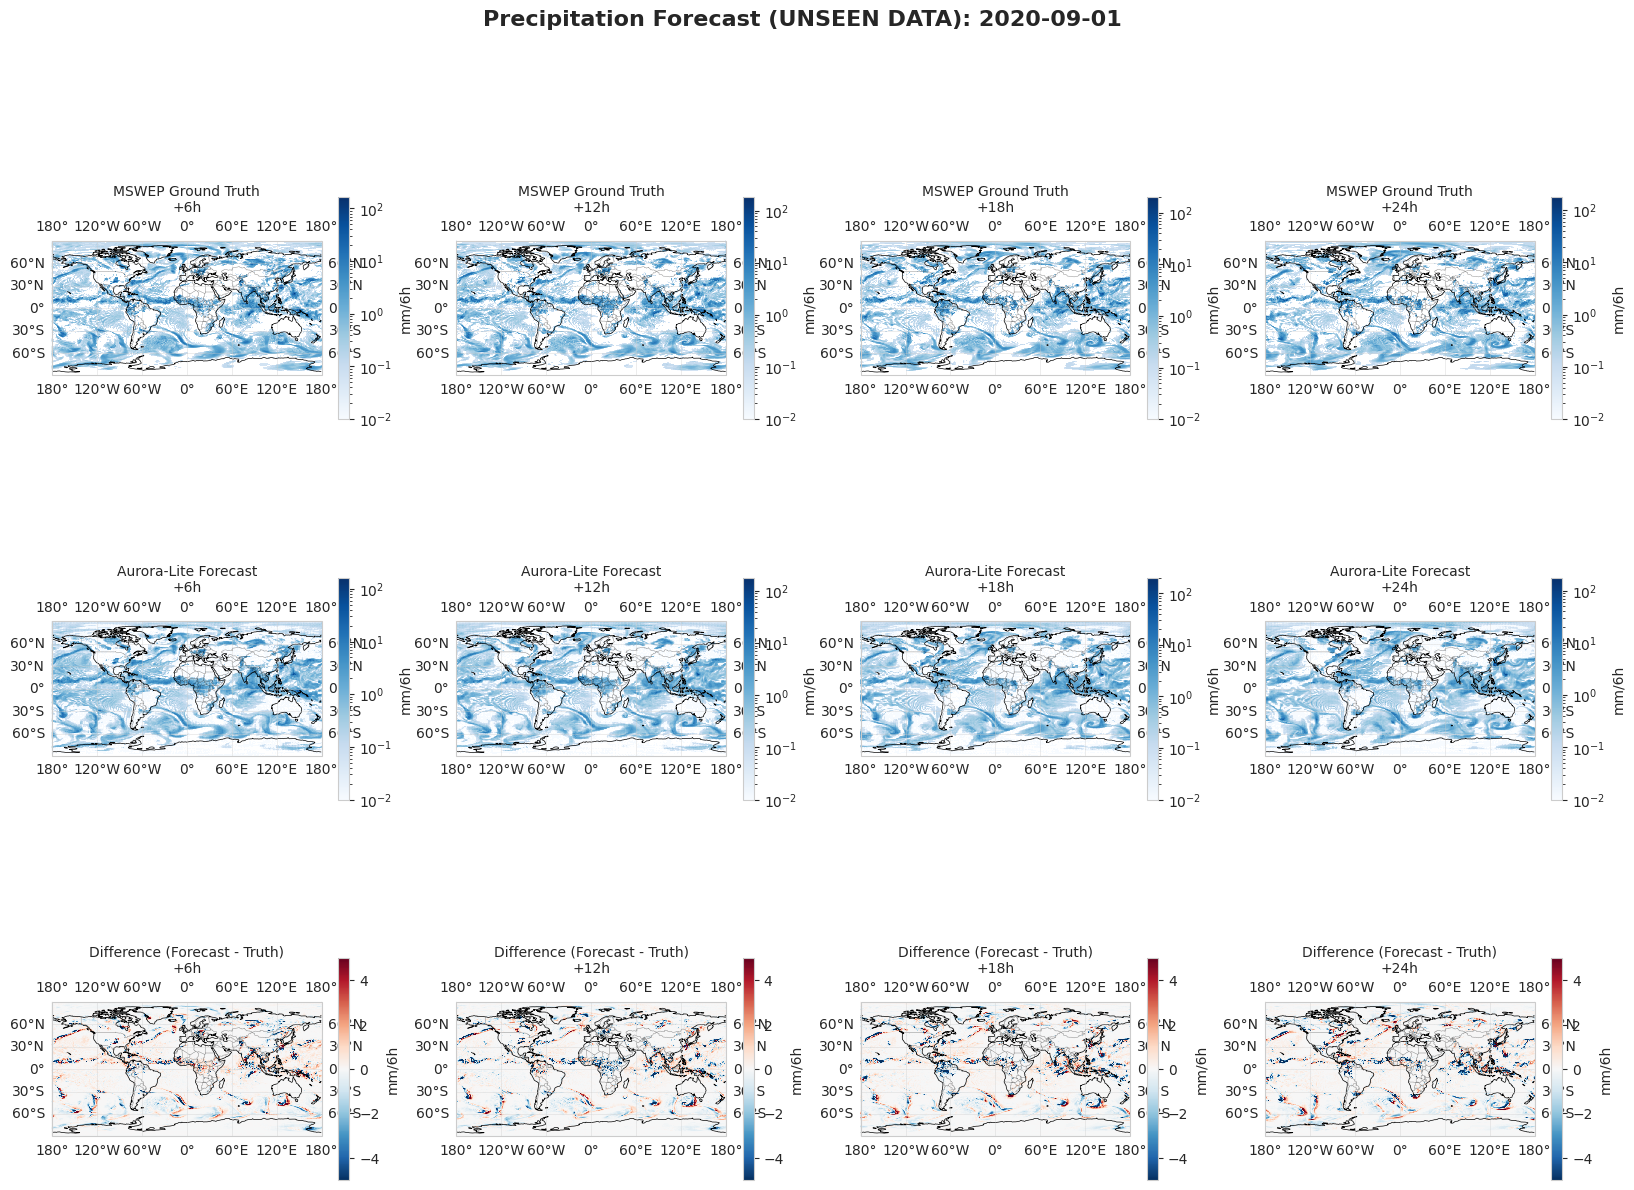


✓ Visualization complete with geographic projections (cartopy)


In [ ]:
# Visualize 2020-09-01 forecast with cartopy
from matplotlib.colors import LogNorm

if len(predictions_2020) > 0:
    # Get lat/lon coordinates from metadata
    lats_2020 = initial_batch_2020.metadata.lat.cpu().numpy()
    lons_2020 = initial_batch_2020.metadata.lon.cpu().numpy()

    # Create figure with cartopy projections
    fig = plt.figure(figsize=(20, 14))
    projection = ccrs.PlateCarree()

    for step in range(min(4, num_steps_2020)):
        pred = predictions_2020[step] * 1000  # Convert to mm
        truth = ground_truth_2020[step] * 1000
        diff = pred - truth

        vmax_precip = max(pred.max(), truth.max(), 0.1)
        vmin_precip = 0.01

        # Ground truth
        ax1 = fig.add_subplot(3, 4, step + 1, projection=projection)
        im1 = ax1.pcolormesh(lons_2020, lats_2020, truth,
                             cmap='Blues',
                             norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
                             transform=projection)
        ax1.coastlines(linewidth=0.5)
        ax1.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax1.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax1.set_title(f'MSWEP Ground Truth\n+{(step+1)*6}h', fontsize=10)
        plt.colorbar(im1, ax=ax1, shrink=0.7, label='mm/6h')

        # Forecast
        ax2 = fig.add_subplot(3, 4, step + 5, projection=projection)
        im2 = ax2.pcolormesh(lons_2020, lats_2020, pred,
                             cmap='Blues',
                             norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
                             transform=projection)
        ax2.coastlines(linewidth=0.5)
        ax2.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax2.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax2.set_title(f'Aurora-Lite Forecast\n+{(step+1)*6}h', fontsize=10)
        plt.colorbar(im2, ax=ax2, shrink=0.7, label='mm/6h')

        # Difference
        ax3 = fig.add_subplot(3, 4, step + 9, projection=projection)
        vmax_diff = max(abs(diff.min()), abs(diff.max()), 0.1)
        im3 = ax3.pcolormesh(lons_2020, lats_2020, diff,
                             cmap='RdBu_r',
                             vmin=-5,
                             vmax=5,
                             transform=projection)
        ax3.coastlines(linewidth=0.5)
        ax3.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax3.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax3.set_title(f'Difference (Forecast - Truth)\n+{(step+1)*6}h', fontsize=10)
        plt.colorbar(im3, ax=ax3, shrink=0.7, label='mm/6h')

    fig.suptitle(f'Precipitation Forecast (UNSEEN DATA): {test_date_2020}', fontsize=16, fontweight='bold')
    # plt.tight_layout()
    plt.show()

    print("\n✓ Visualization complete with geographic projections (cartopy)")

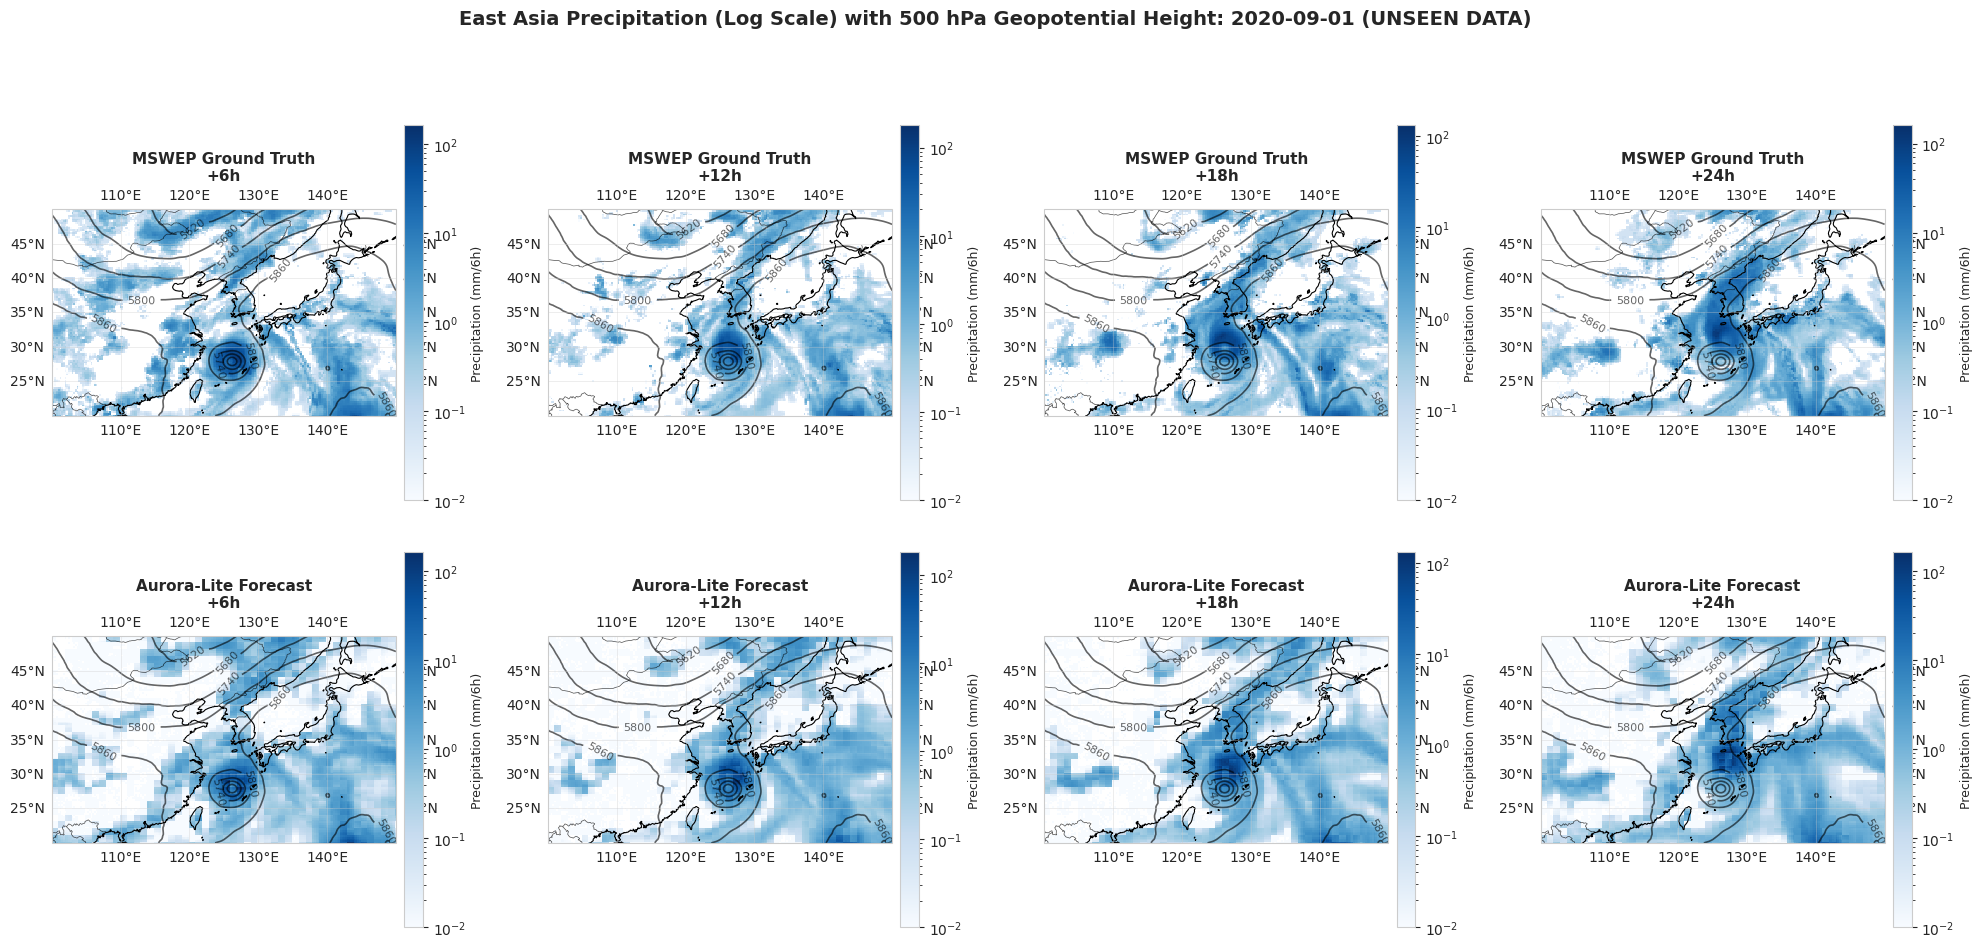


EAST ASIA REGIONAL STATISTICS (2020-09-01 - UNSEEN DATA)
Region: 20°N-50°N, 100°E-150°E
500 hPa geopotential height range: 5583 - 5907 gpm
500 hPa mean geopotential height: 5822 gpm

+6h forecast (East Asia):
  MAE: 0.924 mm/6h
  Correlation: 0.718
  Max precipitation (pred): 164.36 mm/6h
  Max precipitation (truth): 113.18 mm/6h

+12h forecast (East Asia):
  MAE: 0.671 mm/6h
  Correlation: 0.811
  Max precipitation (pred): 181.47 mm/6h
  Max precipitation (truth): 89.79 mm/6h

+18h forecast (East Asia):
  MAE: 0.788 mm/6h
  Correlation: 0.822
  Max precipitation (pred): 131.69 mm/6h
  Max precipitation (truth): 121.96 mm/6h

+24h forecast (East Asia):
  MAE: 1.096 mm/6h
  Correlation: 0.644
  Max precipitation (pred): 162.01 mm/6h
  Max precipitation (truth): 119.88 mm/6h

✓ East Asia regional visualization complete (log scale + 500 hPa geopotential height)


In [ ]:
# East Asia regional focus with 500 hPa geopotential height contours (2020-09-01)
# (Linear scale removed; original linear lines kept as comments)
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

if len(predictions_2020) > 0:
    # Define East Asia region bounds
    lat_min, lat_max = 20, 50  # 20°N to 50°N
    lon_min, lon_max = 100, 150  # 100°E to 150°E

    # Get lat/lon coordinates
    lats_2020_region = initial_batch_2020.metadata.lat.cpu().numpy()
    lons_2020_region = initial_batch_2020.metadata.lon.cpu().numpy()

    # Find indices for East Asia region
    lat_idx = np.where((lats_2020_region >= lat_min) & (lats_2020_region <= lat_max))[0]
    lon_idx = np.where((lons_2020_region >= lon_min) & (lons_2020_region <= lon_max))[0]

    # Extract regional coordinates
    lats_ea = lats_2020_region[lat_idx]
    lons_ea = lons_2020_region[lon_idx]

    # Get 500 hPa geopotential height from initial batch
    # atmos_vars shape: [batch, time, level, lat, lon]
    # Find 500 hPa level index
    atmos_levels = initial_batch_2020.metadata.atmos_levels
    level_500_idx = list(atmos_levels).index(500)

    # Extract 500 hPa geopotential height at initial time (time index 1 = 06:00)
    z_500 = initial_batch_2020.atmos_vars["z"].cpu().numpy()[0, 1, level_500_idx]  # [lat, lon]
    z_500_gpm = z_500 / 9.81  # Convert from m²/s² to geopotential meters (gpm)

    # Extract regional geopotential height at 500 hPa
    z_500_ea = z_500_gpm[np.ix_(lat_idx, lon_idx)]

    # Create subplots for selected forecast steps
    fig = plt.figure(figsize=(20, 10))
    projection = ccrs.PlateCarree()

    steps_to_plot = [0, 1, 2, 3]  # +6h, +12h, +18h, +24h

    for idx, step in enumerate(steps_to_plot):
        pred = predictions_2020[step] * 1000  # Convert to mm
        truth = ground_truth_2020[step] * 1000

        # Extract regional data
        pred_ea = pred[np.ix_(lat_idx, lon_idx)]
        truth_ea = truth[np.ix_(lat_idx, lon_idx)]

        # ---- ORIGINAL (Linear) ----
        # vmax_precip = max(pred_ea.max(), truth_ea.max(), 5.0)
        # vmin_precip = 0.0

        # ---- REVERT to LOG SCALE ----
        vmax_precip = float(max(pred_ea.max(), truth_ea.max(), 0.1))
        vmin_precip = 0.01

        # Ground truth
        ax1 = fig.add_subplot(2, 4, idx + 1, projection=projection)
        im1 = ax1.pcolormesh(
            lons_ea, lats_ea, truth_ea,
            cmap='Blues',
            # vmin=vmin_precip, vmax=vmax_precip,  # (linear, commented)
            norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
            transform=projection
        )

        # Add 500 hPa geopotential height contours
        contours1 = ax1.contour(
            lons_ea, lats_ea, z_500_ea,
            levels=np.arange(5200, 6000, 60),  # 60 gpm intervals
            colors='black', linewidths=1.2, alpha=0.6,
            transform=projection
        )
        ax1.clabel(contours1, inline=True, fontsize=8, fmt='%d')

        ax1.coastlines(linewidth=0.8, color='black')
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        ax1.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
        ax1.set_title(f'MSWEP Ground Truth\n+{(step+1)*6}h', fontsize=11, fontweight='bold')
        cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8, pad=0.02)
        cbar1.set_label('Precipitation (mm/6h)', fontsize=9)

        # Forecast
        ax2 = fig.add_subplot(2, 4, idx + 5, projection=projection)
        im2 = ax2.pcolormesh(
            lons_ea, lats_ea, pred_ea,
            cmap='Blues',
            # vmin=vmin_precip, vmax=vmax_precip,  # (linear, commented)
            norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
            transform=projection
        )

        # Add 500 hPa geopotential height contours
        contours2 = ax2.contour(
            lons_ea, lats_ea, z_500_ea,
            levels=np.arange(5200, 6000, 60),
            colors='black', linewidths=1.2, alpha=0.6,
            transform=projection
        )
        ax2.clabel(contours2, inline=True, fontsize=8, fmt='%d')

        ax2.coastlines(linewidth=0.8, color='black')
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        ax2.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
        ax2.set_title(f'Aurora-Lite Forecast\n+{(step+1)*6}h', fontsize=11, fontweight='bold')
        cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8, pad=0.02)
        cbar2.set_label('Precipitation (mm/6h)', fontsize=9)

    fig.suptitle(
        f'East Asia Precipitation (Log Scale) with 500 hPa Geopotential Height: {test_date_2020} (UNSEEN DATA)',
        fontsize=14, fontweight='bold', y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Print regional statistics
    print("\n" + "=" * 70)
    print("EAST ASIA REGIONAL STATISTICS (2020-09-01 - UNSEEN DATA)")
    print("=" * 70)
    print(f"Region: {lat_min}°N-{lat_max}°N, {lon_min}°E-{lon_max}°E")
    print(f"500 hPa geopotential height range: {z_500_ea.min():.0f} - {z_500_ea.max():.0f} gpm")
    print(f"500 hPa mean geopotential height: {z_500_ea.mean():.0f} gpm")

    for step in steps_to_plot:
        pred_ea = predictions_2020[step][np.ix_(lat_idx, lon_idx)] * 1000
        truth_ea = ground_truth_2020[step][np.ix_(lat_idx, lon_idx)] * 1000

        # Regional metrics
        mae_ea = np.mean(np.abs(pred_ea - truth_ea))
        corr_ea = np.corrcoef(pred_ea.flatten(), truth_ea.flatten())[0, 1]

        print(f"\n+{(step+1)*6}h forecast (East Asia):")
        print(f"  MAE: {mae_ea:.3f} mm/6h")
        print(f"  Correlation: {corr_ea:.3f}")
        print(f"  Max precipitation (pred): {pred_ea.max():.2f} mm/6h")
        print(f"  Max precipitation (truth): {truth_ea.max():.2f} mm/6h")

    print("\n✓ East Asia regional visualization complete (log scale + 500 hPa geopotential height)")


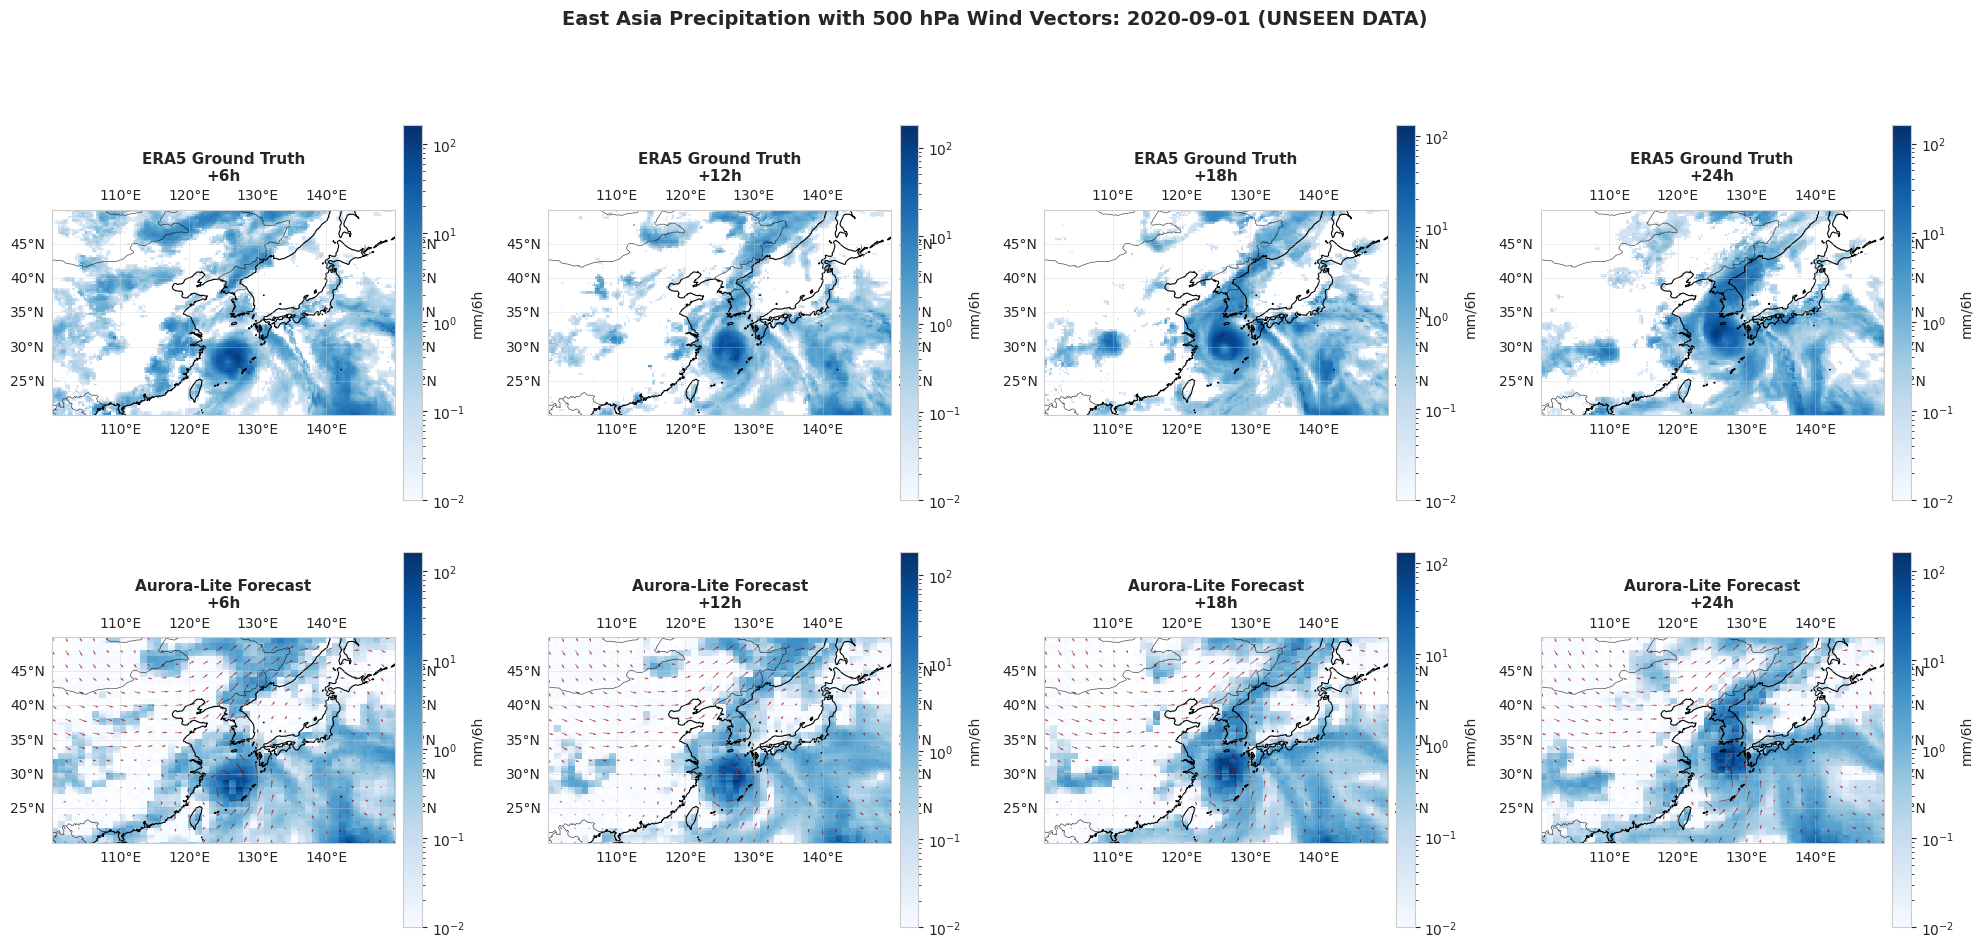


EAST ASIA REGIONAL STATISTICS (2020-09-01 - UNSEEN DATA)
Region: 20°N-50°N, 100°E-150°E
500 hPa wind speed range: 0.10 - 43.52 m/s
500 hPa mean wind speed: 11.69 m/s

+6h forecast (East Asia):
  MAE: 0.924 mm/6h
  Correlation: 0.718
  Max precipitation (pred): 164.36 mm/6h
  Max precipitation (truth): 113.18 mm/6h

+12h forecast (East Asia):
  MAE: 0.671 mm/6h
  Correlation: 0.811
  Max precipitation (pred): 181.47 mm/6h
  Max precipitation (truth): 89.79 mm/6h

+18h forecast (East Asia):
  MAE: 0.788 mm/6h
  Correlation: 0.822
  Max precipitation (pred): 131.69 mm/6h
  Max precipitation (truth): 121.96 mm/6h

+24h forecast (East Asia):
  MAE: 1.096 mm/6h
  Correlation: 0.644
  Max precipitation (pred): 162.01 mm/6h
  Max precipitation (truth): 119.88 mm/6h

✓ East Asia regional visualization complete (500 hPa winds)


In [ ]:
# East Asia regional focus with 500 hPa wind speed overlay (2020-09-01)

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

if len(predictions_2020) > 0:
    # Define East Asia region bounds
    lat_min, lat_max = 20, 50     # 20°N to 50°N
    lon_min, lon_max = 100, 150   # 100°E to 150°E

    # (time index 1 = 06:00)
    u_wind_500 = initial_batch_2020.atmos_vars["u"].cpu().numpy()[0, 1, level_500_idx]  # [lat, lon]
    v_wind_500 = initial_batch_2020.atmos_vars["v"].cpu().numpy()[0, 1, level_500_idx]  # [lat, lon]

    # Extract regional wind at 500 hPa
    u_wind_ea = u_wind_500[np.ix_(lat_idx, lon_idx)]
    v_wind_ea = v_wind_500[np.ix_(lat_idx, lon_idx)]
    wind_speed_ea = np.sqrt(u_wind_ea**2 + v_wind_ea**2)

    # Create subplots for selected forecast steps
    fig = plt.figure(figsize=(20, 10))
    projection = ccrs.PlateCarree()

    steps_to_plot = [0, 1, 2, 3]  # +6h, +12h, +18h, +24h

    for idx, step in enumerate(steps_to_plot):
        pred = predictions_2020[step] * 1000  # Convert to mm
        truth = ground_truth_2020[step] * 1000

        # Extract regional data
        pred_ea = pred[np.ix_(lat_idx, lon_idx)]
        truth_ea = truth[np.ix_(lat_idx, lon_idx)]

        vmax_precip = max(float(pred_ea.max()), float(truth_ea.max()), 0.1)
        vmin_precip = 0.01

        # Ground truth
        ax1 = fig.add_subplot(2, 4, idx + 1, projection=projection)
        im1 = ax1.pcolormesh(
            lons_ea, lats_ea, truth_ea,
            cmap="Blues",
            norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
            transform=projection,
        )
        ax1.coastlines(linewidth=0.8, color="black")
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        gl1 = ax1.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                            linewidth=0.5, alpha=0.5)
        ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
        ax1.set_title(f"ERA5 Ground Truth\n+{(step + 1) * 6}h",
                      fontsize=11, fontweight="bold")
        plt.colorbar(im1, ax=ax1, shrink=0.8, label="mm/6h", pad=0.02)

        # Forecast
        ax2 = fig.add_subplot(2, 4, idx + 5, projection=projection)
        im2 = ax2.pcolormesh(
            lons_ea, lats_ea, pred_ea,
            cmap="Blues",
            norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
            transform=projection,
        )

        # Add 500 hPa wind vectors (subsample for clarity)
        skip = 8  # Plot every 8th vector
        ax2.quiver(
            lons_ea[::skip], lats_ea[::skip],
            u_wind_ea[::skip, ::skip], v_wind_ea[::skip, ::skip],
            transform=projection, alpha=0.7, scale=800, width=0.002,
            color="darkred",
        )

        ax2.coastlines(linewidth=0.8, color="black")
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        gl2 = ax2.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                            linewidth=0.5, alpha=0.5)
        ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
        ax2.set_title(f"Aurora-Lite Forecast\n+{(step + 1) * 6}h",
                      fontsize=11, fontweight="bold")
        plt.colorbar(im2, ax=ax2, shrink=0.8, label="mm/6h", pad=0.02)

    fig.suptitle(
        f"East Asia Precipitation with 500 hPa Wind Vectors: {test_date_2020} (UNSEEN DATA)",
        fontsize=14, fontweight="bold", y=0.98,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Print regional statistics
    print("\n" + "=" * 70)
    print("EAST ASIA REGIONAL STATISTICS (2020-09-01 - UNSEEN DATA)")
    print("=" * 70)
    print(f"Region: {lat_min}°N-{lat_max}°N, {lon_min}°E-{lon_max}°E")
    print(f"500 hPa wind speed range: {wind_speed_ea.min():.2f} - {wind_speed_ea.max():.2f} m/s")
    print(f"500 hPa mean wind speed: {wind_speed_ea.mean():.2f} m/s")

    for step in steps_to_plot:
        pred_ea = predictions_2020[step][np.ix_(lat_idx, lon_idx)] * 1000
        truth_ea = ground_truth_2020[step][np.ix_(lat_idx, lon_idx)] * 1000

        # Regional metrics
        mae_ea = np.mean(np.abs(pred_ea - truth_ea))
        corr_ea = np.corrcoef(pred_ea.flatten(), truth_ea.flatten())[0, 1]

        print(f"\n+{(step + 1) * 6}h forecast (East Asia):")
        print(f"  MAE: {mae_ea:.3f} mm/6h")
        print(f"  Correlation: {corr_ea:.3f}")
        print(f"  Max precipitation (pred): {pred_ea.max():.2f} mm/6h")
        print(f"  Max precipitation (truth): {truth_ea.max():.2f} mm/6h")

    print("\n✓ East Asia regional visualization complete (500 hPa winds)")


## Regional Focus: East Asia with 500 hPa Wind Speed (2020-09-01)

Zoom into East Asia region and overlay 500 hPa wind speed vectors for the 2020 case.

## Test with Unseen Data: September 1, 2020

Now let's test with truly unseen data from 2020 (not used in training).

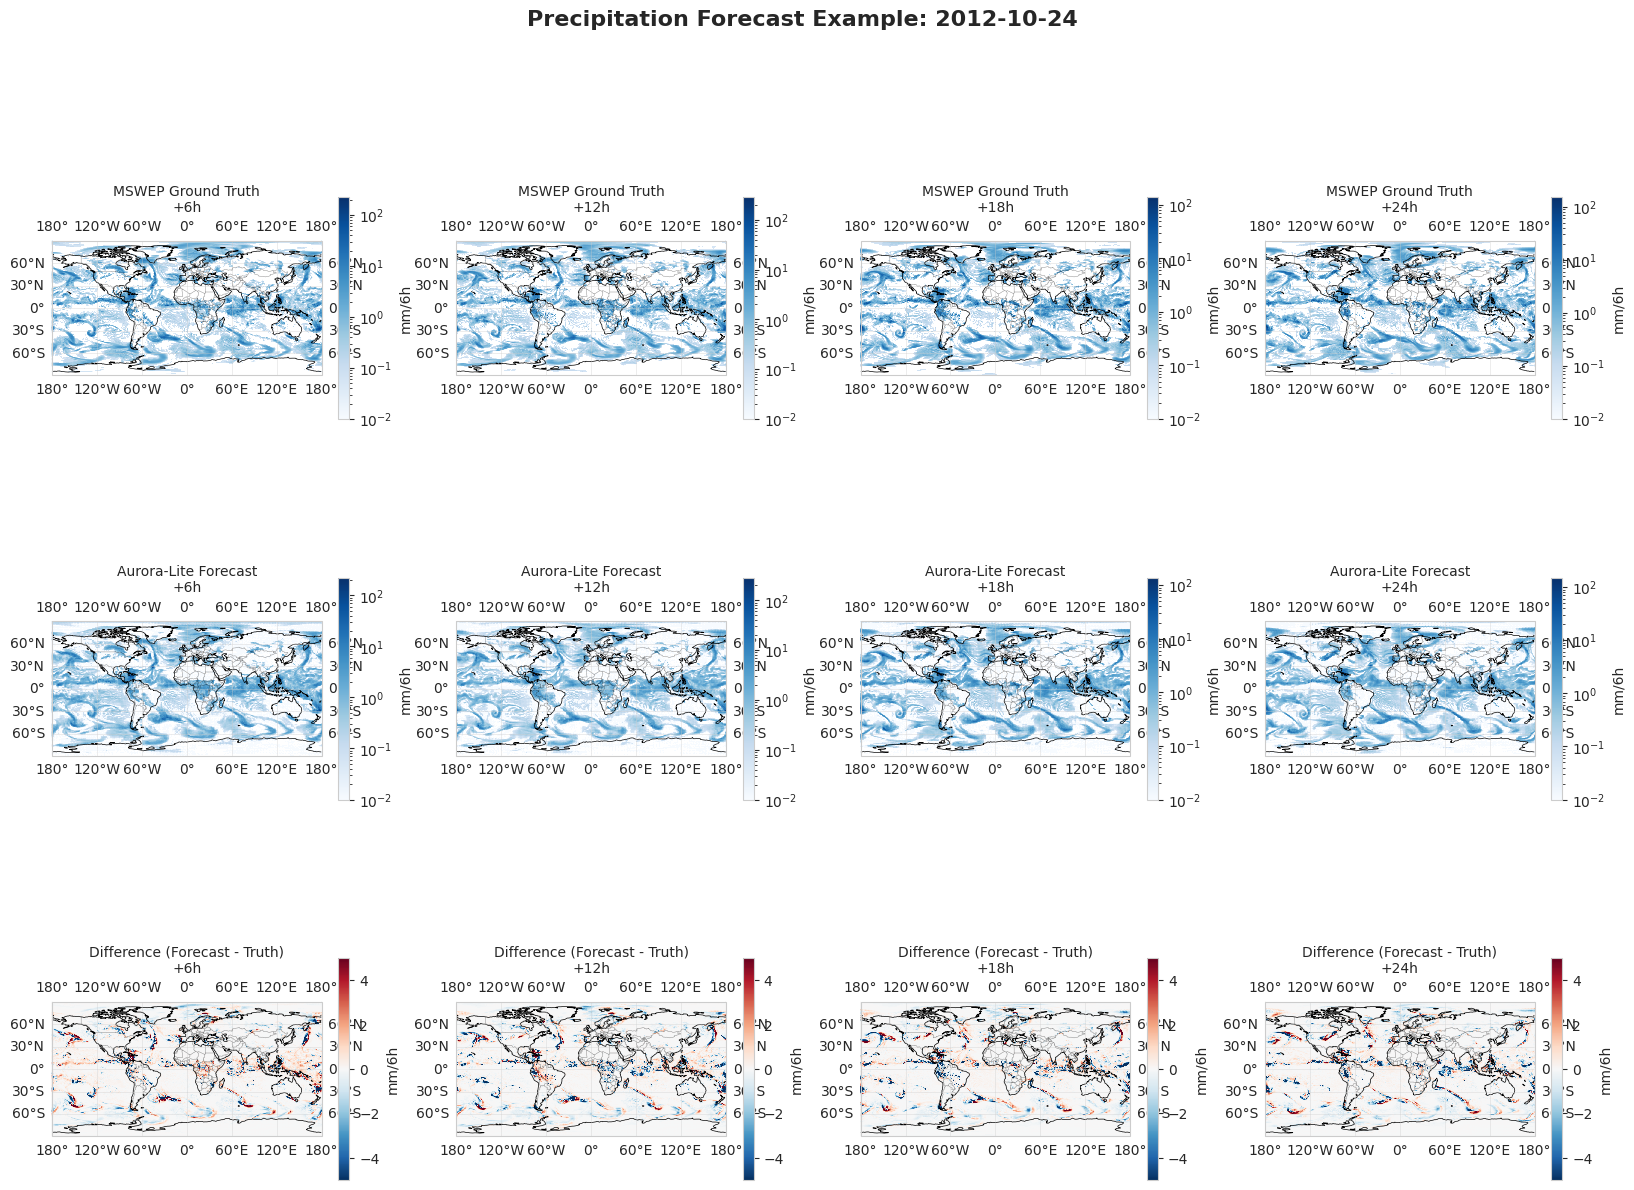


✓ Visualization complete with geographic projections (cartopy)


In [ ]:
# Visualize the single test case with cartopy geographic projections
from matplotlib.colors import LogNorm

if len(predictions) > 0:
    # Get lat/lon coordinates from metadata
    lats = initial_batch.metadata.lat.cpu().numpy()
    lons = initial_batch.metadata.lon.cpu().numpy()

    # Create figure with cartopy projections
    fig = plt.figure(figsize=(20, 14))
    projection = ccrs.PlateCarree()

    for step in range(min(4, num_steps)):
        pred = predictions[step] * 1000  # Convert to mm
        truth = ground_truth[step] * 1000
        diff = pred - truth

        vmax_precip = max(pred.max(), truth.max(), 0.1)
        vmin_precip = 0.01

        # Ground truth
        ax1 = fig.add_subplot(3, 4, step + 1, projection=projection)
        im1 = ax1.pcolormesh(lons, lats, truth,
                             cmap='Blues',
                             norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
                             transform=projection)
        ax1.coastlines(linewidth=0.5)
        ax1.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax1.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax1.set_title(f'MSWEP Ground Truth\n+{(step+1)*6}h', fontsize=10)
        plt.colorbar(im1, ax=ax1, shrink=0.7, label='mm/6h')

        # Forecast
        ax2 = fig.add_subplot(3, 4, step + 5, projection=projection)
        im2 = ax2.pcolormesh(lons, lats, pred,
                             cmap='Blues',
                             norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
                             transform=projection)
        ax2.coastlines(linewidth=0.5)
        ax2.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax2.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax2.set_title(f'Aurora-Lite Forecast\n+{(step+1)*6}h', fontsize=10)
        plt.colorbar(im2, ax=ax2, shrink=0.7, label='mm/6h')

        # Difference
        ax3 = fig.add_subplot(3, 4, step + 9, projection=projection)
        vmax_diff = max(abs(diff.min()), abs(diff.max()), 0.1)
        im3 = ax3.pcolormesh(lons, lats, diff,
                             cmap='RdBu_r',
                             vmin=-5,
                             vmax=5,
                             transform=projection)
        ax3.coastlines(linewidth=0.5)
        ax3.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax3.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax3.set_title(f'Difference (Forecast - Truth)\n+{(step+1)*6}h', fontsize=10)
        plt.colorbar(im3, ax=ax3, shrink=0.7, label='mm/6h')

    fig.suptitle(f'Precipitation Forecast Example: {test_date_str}', fontsize=16, fontweight='bold')
    # plt.tight_layout()
    plt.show()

    print("\n✓ Visualization complete with geographic projections (cartopy)")

In [ ]:
# East Asia regional focus with wind speed overlay
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

if len(predictions) > 0:
    # Define East Asia region bounds
    lat_min, lat_max = 20, 50  # 20°N to 50°N
    lon_min, lon_max = 100, 150  # 100°E to 150°E

    # Get lat/lon coordinates
    lats = initial_batch.metadata.lat.cpu().numpy()
    lons = initial_batch.metadata.lon.cpu().numpy()

    # Find indices for East Asia region
    lat_idx = np.where((lats >= lat_min) & (lats <= lat_max))[0]
    lon_idx = np.where((lons >= lon_min) & (lons <= lon_max))[0]

    # Extract regional data
    lats_region = lats[lat_idx]
    lons_region = lons[lon_idx]

    # Get wind data from initial batch (10m u and v components)
    # Using the second time step (index 1) which is the initial condition at 06:00
    u_wind = initial_batch.surf_vars["10u"].cpu().numpy()[0, 1]  # [batch, time, lat, lon]
    v_wind = initial_batch.surf_vars["10v"].cpu().numpy()[0, 1]

    # Extract regional wind
    u_wind_region = u_wind[np.ix_(lat_idx, lon_idx)]
    v_wind_region = v_wind[np.ix_(lat_idx, lon_idx)]
    wind_speed_region = np.sqrt(u_wind_region**2 + v_wind_region**2)

    # Create subplots for selected forecast steps
    fig = plt.figure(figsize=(20, 10))
    projection = ccrs.PlateCarree()

    steps_to_plot = [0, 1, 2, 3]  # +6h, +12h, +18h, +24h

    for idx, step in enumerate(steps_to_plot):
        pred = predictions[step] * 1000  # Convert to mm
        truth = ground_truth[step] * 1000

        # Extract regional data
        pred_region = pred[np.ix_(lat_idx, lon_idx)]
        truth_region = truth[np.ix_(lat_idx, lon_idx)]

        vmax_precip = max(pred_region.max(), truth_region.max(), 0.1)
        vmin_precip = 0.01

        # Ground truth
        ax1 = fig.add_subplot(2, 4, idx + 1, projection=projection)
        im1 = ax1.pcolormesh(lons_region, lats_region, truth_region,
                             cmap='Blues',
                             norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
                             transform=projection)

        # Add wind vectors (subsample for clarity)
        skip = 8  # Plot every 8th vector
        ax1.quiver(lons_region[::skip], lats_region[::skip],
                   u_wind_region[::skip, ::skip], v_wind_region[::skip, ::skip],
                   transform=projection, alpha=0.6, scale=300, width=0.002)

        ax1.coastlines(linewidth=0.8, color='black')
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        ax1.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
        ax1.set_title(f'MSWEP Ground Truth\n+{(step+1)*6}h', fontsize=11, fontweight='bold')
        plt.colorbar(im1, ax=ax1, shrink=0.8, label='mm/6h', pad=0.02)

        # Forecast
        ax2 = fig.add_subplot(2, 4, idx + 5, projection=projection)
        im2 = ax2.pcolormesh(lons_region, lats_region, pred_region,
                             cmap='Blues',
                             norm=LogNorm(vmin=vmin_precip, vmax=vmax_precip),
                             transform=projection)

        # Add wind vectors
        ax2.quiver(lons_region[::skip], lats_region[::skip],
                   u_wind_region[::skip, ::skip], v_wind_region[::skip, ::skip],
                   transform=projection, alpha=0.6, scale=300, width=0.002)

        ax2.coastlines(linewidth=0.8, color='black')
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        ax2.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.5, alpha=0.5)
        ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
        ax2.set_title(f'Aurora-Lite Forecast\n+{(step+1)*6}h', fontsize=11, fontweight='bold')
        plt.colorbar(im2, ax=ax2, shrink=0.8, label='mm/6h', pad=0.02)

    fig.suptitle(f'East Asia Precipitation Forecast with 10m Wind Vectors: {test_date_str}',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Print regional statistics
    print("\n" + "=" * 70)
    print("EAST ASIA REGIONAL STATISTICS")
    print("=" * 70)
    print(f"Region: {lat_min}°N-{lat_max}°N, {lon_min}°E-{lon_max}°E")
    print(f"Wind speed range: {wind_speed_region.min():.2f} - {wind_speed_region.max():.2f} m/s")
    print(f"Mean wind speed: {wind_speed_region.mean():.2f} m/s")

    for step in steps_to_plot:
        pred_region = predictions[step][np.ix_(lat_idx, lon_idx)] * 1000
        truth_region = ground_truth[step][np.ix_(lat_idx, lon_idx)] * 1000

        # Regional metrics
        mae_region = np.mean(np.abs(pred_region - truth_region))
        corr_region = np.corrcoef(pred_region.flatten(), truth_region.flatten())[0, 1]

        print(f"\n+{(step+1)*6}h forecast (East Asia):")
        print(f"  MAE: {mae_region:.3f} mm/6h")
        print(f"  Correlation: {corr_region:.3f}")
        print(f"  Max precipitation (pred): {pred_region.max():.2f} mm/6h")
        print(f"  Max precipitation (truth): {truth_region.max():.2f} mm/6h")

    print("\n✓ East Asia regional visualization complete")

## Regional Focus: East Asia with Wind Speed

Zoom into East Asia region and overlay 10m wind speed vectors.

## Full Evaluation Loop

**Note**: You'll need to prepare ERA5 data for multiple test dates to run this section.
The evaluation dates should be "unseen" - i.e., not used in model training (e.g., 2020-2021).

In [ ]:
# Define your test dates (adjust based on available ERA5 data)
# According to the paper, test period was January-December 2020
# You can extend to 2021+ for truly "unseen" data

# Example: Monthly samples from 2020
test_dates = pd.date_range("2020-01-15", "2020-12-15", freq='MS')

print(f"Planning to evaluate on {len(test_dates)} dates:")
for date in test_dates:
    print(f"  - {date.strftime('%Y-%m-%d')}")

print(f"\nRollout steps: {ROLLOUT_STEPS} (corresponding to {[s*6 for s in ROLLOUT_STEPS]} hours)")

In [ ]:
# Run evaluation (only execute if you have ERA5 data prepared)
RUN_FULL_EVALUATION = False  # Set to True when ready

if RUN_FULL_EVALUATION:
    # Store results
    results = {
        'dates': [],
        'predictions': {step: [] for step in ROLLOUT_STEPS},
        'ground_truth': {step: [] for step in ROLLOUT_STEPS},
        'metrics': {step: [] for step in ROLLOUT_STEPS},
    }

    # Run evaluation
    for test_date in tqdm(test_dates, desc="Evaluating test cases"):
        try:
            # Load ERA5 batch for initial conditions
            initial_batch = load_era5_batch(test_date, ERA5_DATA_PATH)

            # Perform forward batch forecast
            max_steps = max(ROLLOUT_STEPS)
            predictions = forecast_with_decoder_forward_batch(modelAurora, modelDecoder, initial_batch, max_steps)

            # Get ground truth from MSWEP (6-hourly)
            ground_truth = []
            for step in range(max_steps):
                forecast_time = test_date + timedelta(hours=6*step)
                gt = load_mswep_6hourly(MSWEP_DATA_PATH, forecast_time.strftime("%Y-%m-%d"), forecast_time.hour)
                ground_truth.append(gt)

            # Store results and compute metrics for each rollout length
            results['dates'].append(test_date)

            for step in ROLLOUT_STEPS:
                pred = predictions[step-1]
                truth = ground_truth[step-1]

                # Persistence baseline
                baseline = ground_truth[0] if step > 1 else load_mswep_6hourly(
                    MSWEP_DATA_PATH, test_date.strftime("%Y-%m-%d"), test_date.hour
                )

                # Compute metrics
                metrics = PrecipitationMetrics.compute_all_metrics(pred, truth, baseline)

                results['predictions'][step].append(pred)
                results['ground_truth'][step].append(truth)
                results['metrics'][step].append(metrics)

        except Exception as e:
            print(f"\nError processing {test_date}: {e}")
            continue

    print("\n✓ Evaluation complete!")
else:
    print("Full evaluation skipped (RUN_FULL_EVALUATION=False)")
    print("Set RUN_FULL_EVALUATION=True and ensure ERA5 data is prepared to run full evaluation.")

## Summary

This notebook provides a framework for evaluating Aurora-Lite Decoder on unseen MSWEP precipitation data.

### Next Steps:

1. **Prepare ERA5 Data**: Download ERA5 atmospheric data for your chosen evaluation dates
2. **Run Full Evaluation**: Set `RUN_FULL_EVALUATION=True` and execute the evaluation loop
3. **Analyze Results**: Use the visualization cells (similar to the single case example) to examine model performance
4. **Extend Analysis**: Add more sophisticated metrics, regional analysis, or seasonal comparisons

### Key Findings to Look For:

- How does forecast skill degrade with lead time?
- Does the model perform better/worse in certain regions or seasons?
- How well does it capture precipitation extremes vs. light rain?
- What is the skill score relative to persistence baseline?